# Full project notebook

## All imports

In [ ]:
import os
import re
import nltk
import math
import json
import torch
import random
import hashlib
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.stats import norm
from wordcloud import WordCloud
from nltk.corpus import stopwords
from scipy.sparse import csr_matrix
from scipy.spatial.distance import cdist
from sklearn.preprocessing import normalize
from collections import defaultdict, Counter
from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge, LogisticRegression
from transformers import AutoTokenizer, AutoConfig, AutoModel

PROJECT_ROOT = "."

## Data preparation

We first gather the datasets that we are going to use for this study. 
One dataset is used for training and validation, a separate dataset is used to test it on a completely different corpus.

In [2]:

os.makedirs("plots", exist_ok=True)
os.makedirs("datasets", exist_ok=True)

files = {
    "datasets/All_Beauty.jsonl": "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/All_Beauty.jsonl",
    "datasets/Handmade_Products.jsonl": "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Handmade_Products.jsonl",
}

for path, url in files.items():
    if not os.path.exists(path):
        import urllib.request
        urllib.request.urlretrieve(url, path)


After downloading, we filter the dataset to remove all unnecessary information and use fixed category sizes.

In [3]:
def filter_jsonl(input_path, output_path, max_per_rating=50000):
    keep_keys = {"rating", "title", "text"}
    rating_counts_before = defaultdict(int)
    rating_counts_after = defaultdict(int)

    # First pass: count existing reviews per rating
    with open(input_path, "r", encoding="utf-8") as fin:
        for line in fin:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                rating = int(data.get("rating", 0))
                if rating in [1, 2, 3, 4, 5]:
                    rating_counts_before[rating] += 1
            except json.JSONDecodeError:
                continue

    # Second pass: write filtered output with limit
    with (
        open(input_path, "r", encoding="utf-8") as fin,
        open(output_path, "w", encoding="utf-8") as fout,
    ):
        for line in fin:
            if not line.strip():
                continue
            try:
                data = json.loads(line)
                rating = int(data.get("rating", 0))
                if rating not in [1, 2, 3, 4, 5]:
                    continue
                if rating_counts_after[rating] >= max_per_rating:
                    continue

                filtered = {k: data[k] for k in keep_keys if k in data}
                fout.write(json.dumps(filtered, ensure_ascii=False) + "\n")
                rating_counts_after[rating] += 1

                # stop early if all limits reached
                if all(
                    rating_counts_after[r] >= max_per_rating for r in [1, 2, 3, 4, 5]
                ):
                    break

            except json.JSONDecodeError:
                continue

    # Print results
    print(f"File: {input_path}")
    print("Rating | Before | After")
    for r in [1, 2, 3, 4, 5]:
        before = rating_counts_before[r]
        after = rating_counts_after[r]
        print(f"  {r}    |  {before}  |  {after}")

if not os.path.exists(os.path.join(PROJECT_ROOT, "datasets", "All_Beauty_f.jsonl")):
    filter_jsonl(
        os.path.join(PROJECT_ROOT, "datasets", "All_Beauty.jsonl"),
        os.path.join(PROJECT_ROOT, "datasets", "All_Beauty_f.jsonl"),
        40000,
    )

if not os.path.exists(os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products_f.jsonl")):
    filter_jsonl(
        os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products.jsonl"),
        os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products_f.jsonl"),
        20000,
    )

For easier handling, we define a torch dataset and create splits for our processing purposes.

In [4]:
class ReviewDataset(Dataset):
    def __init__(self, path, indices):
        self.path = path
        self.indices = indices
        self.offsets = []
        with open(path, "rb") as f:
            pos = 0
            for line in f:
                self.offsets.append(pos)
                pos += len(line)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        file_idx = self.indices[idx]
        with open(self.path, "rb") as f:
            f.seek(self.offsets[file_idx])
            line = f.readline().decode("utf-8")
            data = json.loads(line)
        text = f"{data.get('title', '')}: {data.get('text', '')}"
        rating = float(data.get("rating", 0.0))
        return text, rating


def make_splits(path, train_ratio=0.8, val_ratio=0.1, seed=42):
    offsets = []
    with open(path, "r", encoding="utf-8") as f:
        for i, _ in enumerate(f):
            offsets.append(i)
    random.seed(seed)
    random.shuffle(offsets)

    n = len(offsets)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_idx = offsets[:n_train]
    val_idx = offsets[n_train : n_train + n_val]
    test_idx = offsets[n_train + n_val :]

    train_ds = ReviewDataset(path, train_idx)
    val_ds = ReviewDataset(path, val_idx)
    test_ds = ReviewDataset(path, test_idx)
    return train_ds, val_ds, test_ds


train_ds, val_ds, _ = make_splits(
    os.path.join(PROJECT_ROOT, "datasets", "All_Beauty_f.jsonl")
)
_, _, test_ds = make_splits(
    os.path.join(PROJECT_ROOT, "datasets", "Handmade_Products_f.jsonl"), 0.7
)
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))
print("First training sample:", train_ds[0])


Train size: 160000
Val size: 20000
Test size: 20000
First training sample: ('Muy útil!: Me gusto mucho, pero algunas letras vi jeringas borradas!', 4.0)


### Sentence Transformer (for clustering and indexFlatIP)

Below we provide a novel implementation of SBERT as a sentence transformer to generate embeddings from text input. This will be used for clustering and index search.

In [5]:
class PairwiseRatingDataset(Dataset):
    """
    Wraps ReviewDataset.
    For each __getitem__, returns a random pair of review texts
    and a similarity label derived from the ratings.
    """

    def __init__(self, review_dataset):
        self.ds = review_dataset
        self.max_rating = max(r for _, r in self.ds)

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        t1, r1 = self.ds[idx]
        rand_idx = random.randint(0, len(self.ds) - 1)
        t2, r2 = self.ds[rand_idx]
        sim = 1.0 - abs(r1 - r2) / self.max_rating
        sim = torch.tensor(sim, dtype=torch.float32)
        return t1, t2, sim


class MeanPooling(nn.Module):
    """
    Averages token embeddings using the attention mask
    """

    def forward(self, token_embeddings, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        masked = token_embeddings * mask
        summed = masked.sum(dim=1)
        counted = mask.sum(dim=1)
        return summed / counted


class BasicSBERT(nn.Module):
    """
    Very basic transformer model based on SBERT using just an encoder and mean pooling
    """

    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.pool = MeanPooling()

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_embeddings = outputs.last_hidden_state
        return self.pool(token_embeddings, attention_mask)


class ContrastiveLoss(nn.Module):
    """
    Loss function using contrastive cosine similarity;
    uses sigmoid to push high similarity for positives towards 1 and low similarity towards -1
    """

    def __init__(self, temperature=0.07):
        super().__init__()
        self.temperature = temperature
        self.cos = nn.CosineSimilarity(dim=-1)

    def forward(self, emb1, emb2, labels):
        sim = self.cos(emb1, emb2) / self.temperature
        pos = -labels * torch.log(torch.sigmoid(sim) + 1e-8)
        neg = -(1 - labels) * torch.log(1 - torch.sigmoid(sim) + 1e-8)
        return (pos + neg).mean()


def build_transformer():
    config = AutoConfig.from_pretrained(
        "bert-base-uncased",
        hidden_size=128,
        num_hidden_layers=2,
        num_attention_heads=4,
        intermediate_size=256,
    )
    encoder = AutoModel.from_config(config)
    return BasicSBERT(encoder)


def collate_batch(batch, tokenizer):
    """
    Tokenizes two parallel lists of texts and stacks their similarity labels
    """
    texts1 = [b[0] for b in batch]
    texts2 = [b[1] for b in batch]
    labels = torch.stack([b[2] for b in batch])

    enc1 = tokenizer(texts1, return_tensors="pt", padding=True, truncation=True)
    enc2 = tokenizer(texts2, return_tensors="pt", padding=True, truncation=True)

    if "token_type_ids" in enc1:
        del enc1["token_type_ids"]
        del enc2["token_type_ids"]

    return enc1, enc2, labels


def train_sentence_transformer(train_ds, epochs=1, batch_size=16, lr=2e-5):
    """
    Training function for transformer
    """
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = build_transformer()
    pairwise_dataset = PairwiseRatingDataset(train_ds)

    dataloader = DataLoader(
        pairwise_dataset,
        batch_size=batch_size,
        shuffle=True,
        collate_fn=lambda b: collate_batch(b, tokenizer),
    )

    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = ContrastiveLoss()

    for ep in range(epochs):
        print(f"Epoch {ep + 1}/{epochs}")
        for step, (enc1, enc2, labels) in enumerate(dataloader):
            emb1 = model(**enc1)
            emb2 = model(**enc2)
            loss = loss_fn(emb1, emb2, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if step % 50 == 0:
                print(f"  Step {step}, Loss = {loss.item():.4f}")

    return model, tokenizer


def encode_texts(model, tokenizer, texts, batch_size=64):
    """
    Encodes list of texts into embeddings using model and tokenizer
    """
    all_embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
        )
        enc.pop("token_type_ids", None)
        enc.pop("position_ids", None)

        with torch.no_grad():
            emb = model(**enc)

        all_embeddings.append(emb)
    return torch.cat(all_embeddings, dim=0).cpu().numpy()

Now we need to train the model. We only do one epoch, since the focus of this project is on data science and not transformers. For easier re-execution, we only train the model if saved files don't exist.

In [6]:
try:
    print("Trying to load pre-trained sentence transformer...")
    model = build_transformer()
    model.load_state_dict(
        torch.load(
            os.path.join(PROJECT_ROOT, "sentence_tranformer_weights.pth"),
            map_location="cpu",
        )
    )
    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(
        os.path.join(PROJECT_ROOT, "tokenizer/")
    )
except Exception:
    print("Training sentence transformer...")
    model, tokenizer = train_sentence_transformer(train_ds, epochs=1)
    torch.save(model.state_dict(), os.path.join(PROJECT_ROOT, "sentence_tranformer_weights.pth"))
    tokenizer.save_pretrained(os.path.join(PROJECT_ROOT, "tokenizer/"))
    model.eval()

Trying to load pre-trained sentence transformer...


## Simple Baseline

As a simple baseline we use a dictionary which assigns the average rating of that word as the sentiment score. We use the two functions below for this.

In [ ]:
# Download stopwords to ./nltk_data
nltk.download("stopwords", quiet=True)
# Load stopwords
stop_words = set(stopwords.words("english"))

def build_word_stats(dataset):
    word_stats = defaultdict(lambda: {"score": 0.0, "count": 0})
    word_pattern = re.compile(r"\b\w+\b")
    for text, rating in tqdm(dataset, desc="Processing reviews"):
        words = [x for x in word_pattern.findall(text.lower()) if x not in stop_words]
        for word in words:
            if len(word) > 1 and word.isalpha():
                word_stats[word]["score"] += rating
                word_stats[word]["count"] += 1

    for k, v in word_stats.items():
        word_stats[k]["avg"] = v["score"] / v["count"]

    return word_stats,


def assign_sentiment(word_stats, dataset):
    """
    Compute sentiment scores for each word using the global mean of ratings
    and optional exponential scaling.
    """
    total_count = 0
    total_score_sum = 0.0
    sum_squared_diff = 0.0

    for _, rating in tqdm(dataset, desc="Calculating global mean and std"):
        total_score_sum += rating
        total_count += 1

    global_mean = total_score_sum / total_count

    for _, rating in tqdm(dataset, desc="Calculating variance"):
        sum_squared_diff += (rating - global_mean) ** 2

    global_std = math.sqrt(sum_squared_diff / total_count)

    for stats in word_stats.values():
        diff = stats["avg"] - global_mean
        stats["sentiment"] = np.sign(diff) * diff**2

    return word_stats, global_mean, global_std

Lets see what the baseline dictionary looks like:

In [ ]:
word_stats, global_mean, global_std = assign_sentiment(
        *build_word_stats(train_ds), train_ds
)
print("Average review score:", global_mean)
print("Example word stats:", list(word_stats.items())[:5])

Below we define some plotting functions which we use to get a better understanding of how our data looks.

In [ ]:
# Constants
WORD_PATTERN = re.compile(r"\b\w+\b")
RATING_COLORS = {
    1: (139, 0, 0),  # darkred - Very negative
    2: (255, 0, 0),  # red - Negative
    3: (255, 165, 0),  # orange - Neutral
    4: (144, 238, 144),  # lightgreen - Positive
    5: (0, 100, 0),  # darkgreen - Very positive
}
# Download stopwords to ./nltk_data
nltk.download("stopwords", quiet=True)
# Load stopwords
stop_words = set(stopwords.words("english"))


def plot_word_sentiment_distribution(word_stats, bins=50, savefig=True, prefix=""):
    sentiments = [v["sentiment"] for v in word_stats.values()]

    plt.figure(figsize=(8, 5))
    plt.hist(sentiments, bins=bins, color="skyblue", edgecolor="black")
    plt.title("Word Sentiment Distribution")
    plt.xlabel("Sentiment Score")
    plt.ylabel("Number of Words")
    plt.grid(axis="y", alpha=0.75)
    
    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    
    if savefig:
        plt.savefig(
            os.path.join(plots_dir, f"{prefix}_SentimentDistribution_baseline.png")
        )
    else:
        plt.show()


def plot_word_cloud(word_stats, top_words=100, savefig=True, prefix=""):
    top_items = sorted(word_stats.items(), key=lambda x: x[1]["count"], reverse=True)[
        :top_words
    ]
    freq_dict = {k: v["count"] for k, v in top_items}

    min_score = 1.0
    max_score = 5.0
    word_avg_scores = {
        k: min(max(v["avg"], min_score), max_score) for k, v in top_items
    }

    def color_func(word, **kwargs):
        score = word_avg_scores.get(word, 3.0)
        norm_score = (score - min_score) / (max_score - min_score)
        r = int(255 * (1 - norm_score))
        g = int(255 * norm_score)
        b = 0
        return f"rgb({r},{g},{b})"

    wordcloud = WordCloud(
        width=800, height=400, background_color="white"
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(12, 6))
    plt.imshow(
        wordcloud.recolor(color_func=color_func, random_state=42),
        interpolation="bilinear",
    )
    plt.axis("off")
    plt.title(f"Word Cloud of Top {top_words} Words (colored by avg score)")
    
    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    
    if savefig:
        plt.savefig(os.path.join(plots_dir, f"{prefix}_Wordcloud_baseline.png"))
    else:
        plt.show()


def _count_word_frequencies(words, top_words):
    word_freq = defaultdict(int)
    for word in words:
        word_freq[word] += 1
    top_items = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:top_words]
    return dict(top_items), word_freq


def _create_wordcloud(freq_dict, color_rgb, width, height, max_words):
    def color_func(word, font_size, position, orientation, random_state=None, **kwargs):
        return color_rgb

    return WordCloud(
        width=width,
        height=height,
        background_color="white",
        color_func=color_func,
        max_words=max_words,
        relative_scaling=0.5,
    ).generate_from_frequencies(freq_dict)


def generate_rating_wordclouds(dataset, prefix="", top_words=100):
    rating_texts = defaultdict(list)

    print("Grouping reviews by rating...")
    for text, rating in tqdm(dataset, desc="Processing reviews"):
        rating = int(rating)
        if rating in [1, 2, 3, 4, 5]:
            words = [
                x.lower()
                for x in WORD_PATTERN.findall(text.lower())
                if x.lower() not in stop_words and len(x) > 1 and x.isalpha()
            ]
            rating_texts[rating].extend(words)

    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    print("\nGenerating word clouds for each rating...")
    for rating in sorted(rating_texts.keys()):
        words = rating_texts[rating]
        if len(words) == 0:
            print(f"Warning: No words found for rating {rating}")
            continue

        freq_dict, word_freq = _count_word_frequencies(words, top_words)

        if len(freq_dict) == 0:
            print(f"Warning: No words to display for rating {rating}")
            continue

        wordcloud = _create_wordcloud(
            freq_dict, RATING_COLORS[rating], 1200, 600, top_words
        )

        plt.figure(figsize=(14, 7))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(
            f"Word Cloud for Rating {rating} ({len(rating_texts[rating])} words, {len(word_freq)} unique)",
            fontsize=16,
            fontweight="bold",
        )

        filename = f"{prefix}Wordcloud_Rating{rating}_tfidf.png"
        savepath = os.path.join(plots_dir, filename)
        plt.savefig(savepath, dpi=150, bbox_inches="tight")

        print(f"  Rating {rating}: {len(word_freq)} unique words, saved to {filename}")

    print("\nGenerating comparison plot...")
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    for idx, rating in enumerate(sorted(rating_texts.keys())):
        words = rating_texts[rating]
        if len(words) == 0:
            continue

        freq_dict, _ = _count_word_frequencies(words, top_words)

        if len(freq_dict) == 0:
            continue

        wordcloud = _create_wordcloud(
            freq_dict, RATING_COLORS[rating], 400, 200, top_words
        )

        axes[idx].imshow(wordcloud, interpolation="bilinear")
        axes[idx].axis("off")
        axes[idx].set_title(f"Rating {rating}", fontsize=12, fontweight="bold")

    plt.suptitle(
        "Word Clouds by Rating - Community Comparison",
        fontsize=16,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()

    filename = f"{prefix}Wordcloud_Comparison_tfidf.png"
    savepath = os.path.join(plots_dir, filename)
    plt.savefig(savepath, dpi=150, bbox_inches="tight")

    print(f"  Comparison plot saved to {filename}")

Calculating variance: 100%|██████████| 160000/160000 [00:02<00:00, 69661.65it/s]


Average review score: 2.99805
Example word stats: [('muy', {'score': 1903.0, 'count': 632, 'avg': 3.0110759493670884, 'sentiment': np.float64(0.00016967535691394915)}), ('útil', {'score': 39.0, 'count': 10, 'avg': 3.9, 'sentiment': np.float64(0.8135138024999996)}), ('gusto', {'score': 283.0, 'count': 120, 'avg': 2.3583333333333334, 'sentiment': np.float64(-0.40923741361111116)}), ('mucho', {'score': 322.0, 'count': 104, 'avg': 3.0961538461538463, 'sentiment': np.float64(0.009624364630177514)}), ('pero', {'score': 939.0, 'count': 335, 'avg': 2.8029850746268656, 'sentiment': np.float64(-0.03805032511082652)})]
Grouping reviews by rating...


Processing reviews: 100%|██████████| 160000/160000 [00:04<00:00, 35260.59it/s]



Generating word clouds for each rating...
  Rating 1: 19740 unique words, saved to Wordcloud_Rating1_tfidf.png
  Rating 2: 20225 unique words, saved to Wordcloud_Rating2_tfidf.png
  Rating 3: 21078 unique words, saved to Wordcloud_Rating3_tfidf.png
  Rating 4: 22795 unique words, saved to Wordcloud_Rating4_tfidf.png
  Rating 5: 21705 unique words, saved to Wordcloud_Rating5_tfidf.png

Generating comparison plot...
  Comparison plot saved to Wordcloud_Comparison_tfidf.png


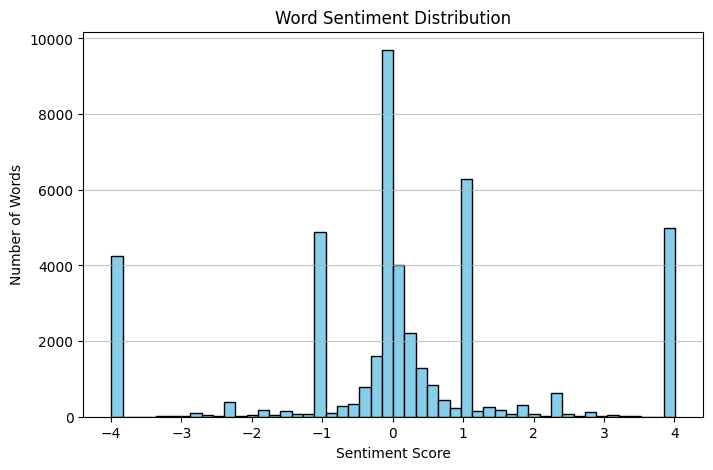

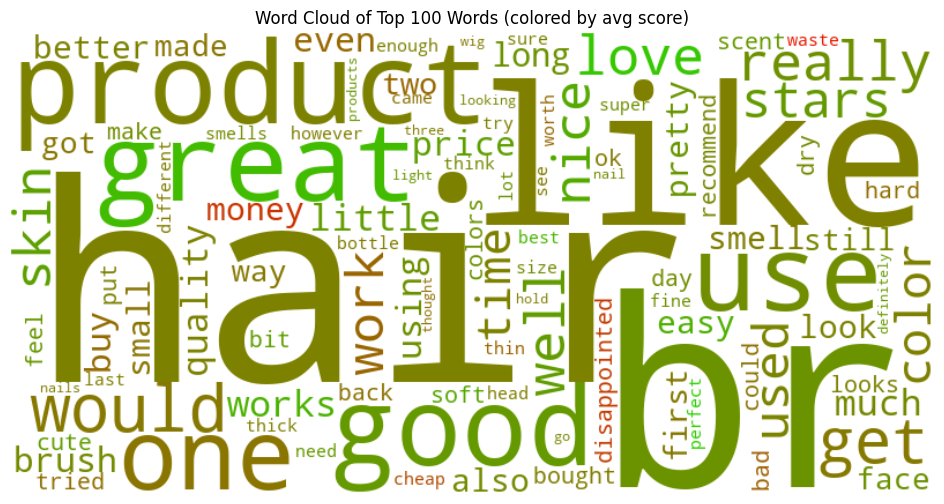

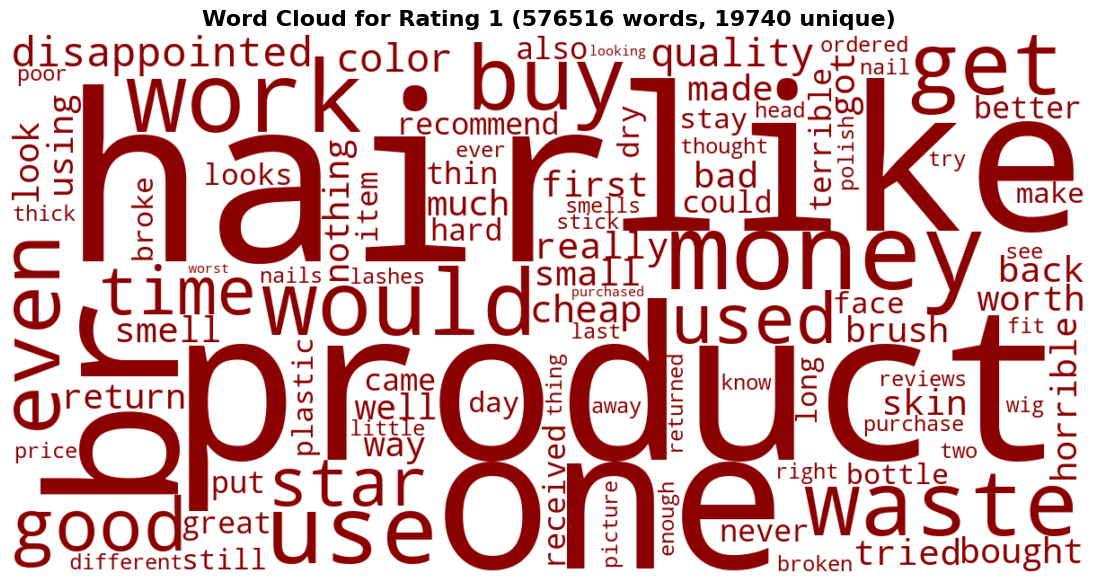

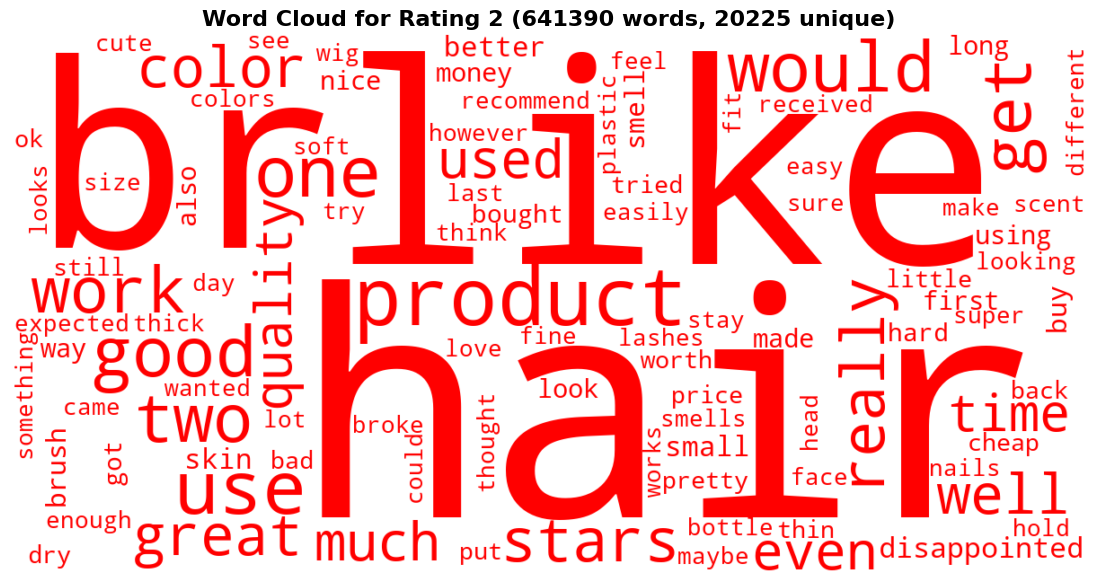

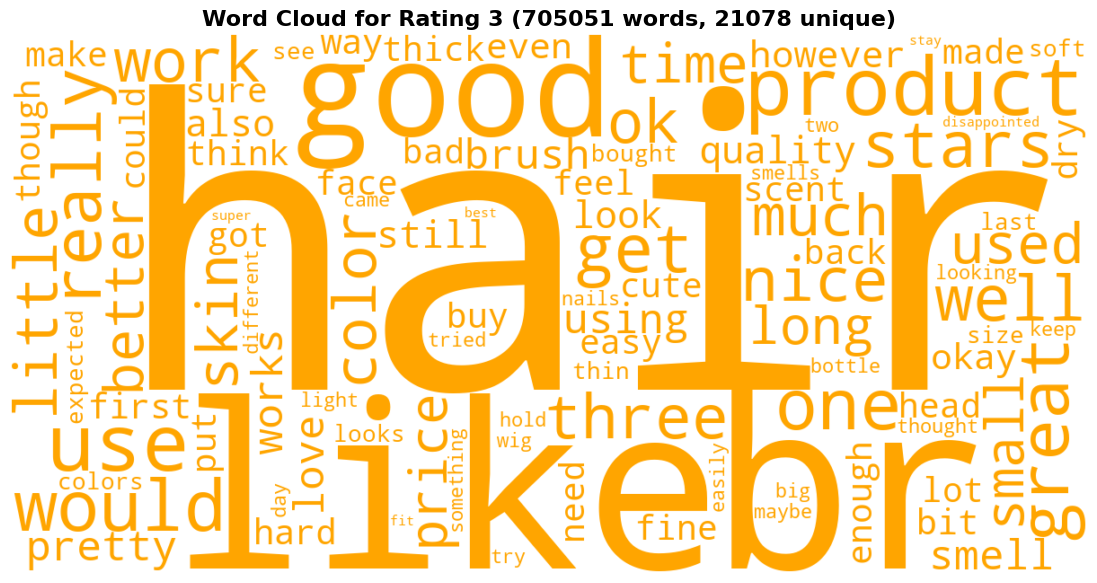

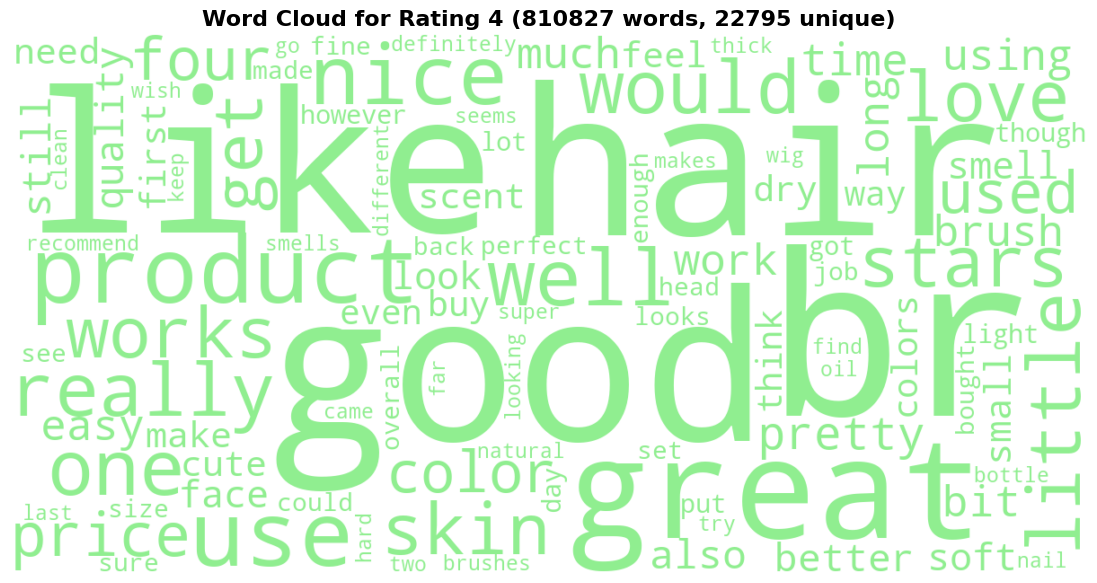

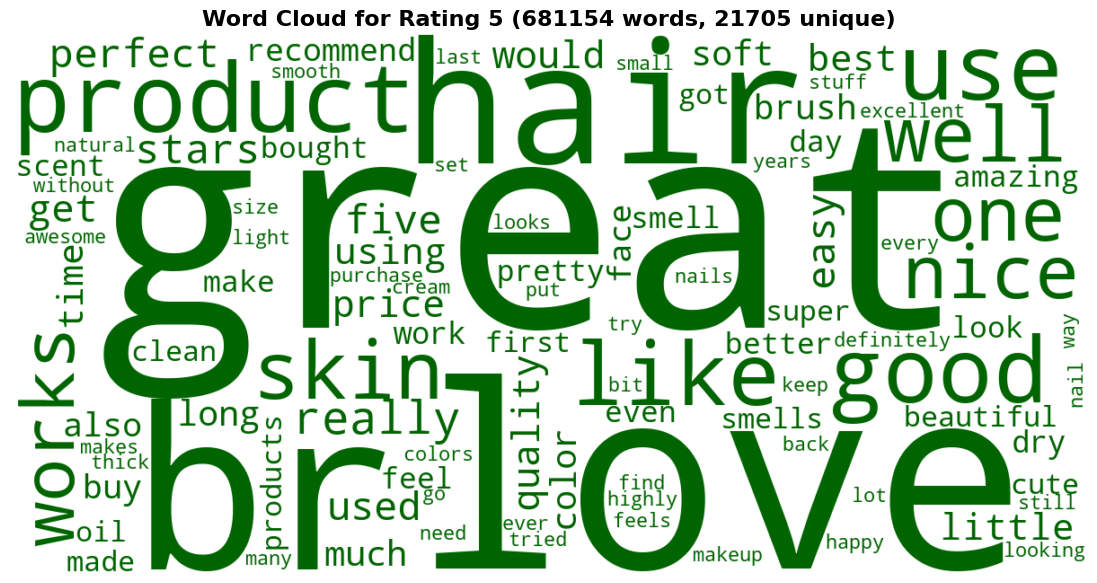

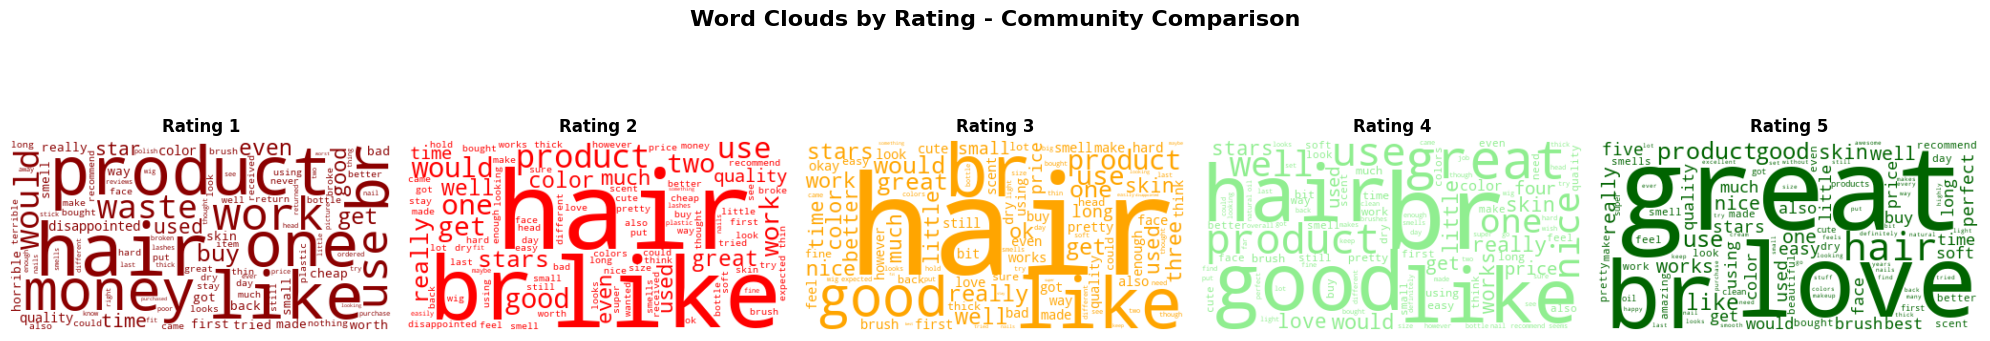

In [3]:
plot_word_sentiment_distribution(word_stats, bins=50)
plot_word_cloud(word_stats, top_words=100)
generate_rating_wordclouds(train_ds, prefix="", top_words=100)

Now we define more plotting functions to have some comparative basis for our different models:

In [7]:
def mse_plot(scores, mse_values, counts, savepath=None):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(scores, mse_values, width=0.4, color="skyblue", edgecolor="black")
    plt.xlabel("True Review Score")
    plt.ylabel("Mean Squared Error (MSE)")
    plt.title("Word-Sentiment Reconstruction Error per Score")
    plt.grid(axis="y", alpha=0.7)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            "@" + str(count) + " rev's",
            ha="center",
            va="bottom",
            fontsize=10,
        )
    if savepath:
        plt.savefig(savepath)
    else:
        plt.show()


def confusion_plot(true_scores, pred_scores, savepath=None):
    all_scores = sorted(set([int(x) for x in true_scores]))
    confusion = pd.DataFrame(0, index=all_scores, columns=all_scores)

    for t, p in zip(true_scores, pred_scores):
        confusion.loc[t, round(p, 0)] += 1

    confusion_percent = confusion.div(confusion.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        confusion_percent,
        annot=True,
        fmt=".1f",
        cmap="viridis",
        cbar=True,
        xticklabels=all_scores,
        yticklabels=all_scores,
        vmin=0,
        vmax=60,
    )
    plt.xlabel("Predicted Score (rounded)")
    plt.ylabel("True Score")
    plt.title("Prediction Confusion Matrix (% per True Score)")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    else:
        plt.show()


def make_analysis(true_scores, pred_scores, prefix="", suffix=""):
    true_scores = np.array(true_scores)
    pred_scores = np.array(pred_scores)

    diff = np.abs(pred_scores - true_scores)
    mse = np.mean(np.where(diff >= 0.5, diff**2, 0))
    print(f"Overall MSE: {mse:.4f}")

    per_score_mse = defaultdict(list)
    per_score_count = defaultdict(int)
    for t, p in zip(true_scores, pred_scores):
        per_score_mse[t].append((p - t) ** 2)
        per_score_count[t] += 1

    scores = sorted(per_score_mse.keys())
    mse_values = [np.mean(per_score_mse[s]) for s in scores]
    counts = [per_score_count[s] for s in scores]

    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)

    mse_plot(
        scores,
        mse_values,
        counts,
        savepath=os.path.join(plots_dir, prefix + "ErrorPerScore_" + suffix + ".png"),
    )

    confusion_plot(
        true_scores,
        pred_scores,
        savepath=os.path.join(plots_dir, prefix + "ConfusionMatrix_" + suffix + ".png"),
    )


Building the baseline was successful. Now, we should look at how it performs:

Running test: 100%|██████████| 20000/20000 [00:00<00:00, 23610.41it/s]


Overall MSE: 1.1195
Number of unknown words: 492


Running test: 100%|██████████| 20000/20000 [00:00<00:00, 28925.27it/s]


Overall MSE: 1.1606
Number of unknown words: 539


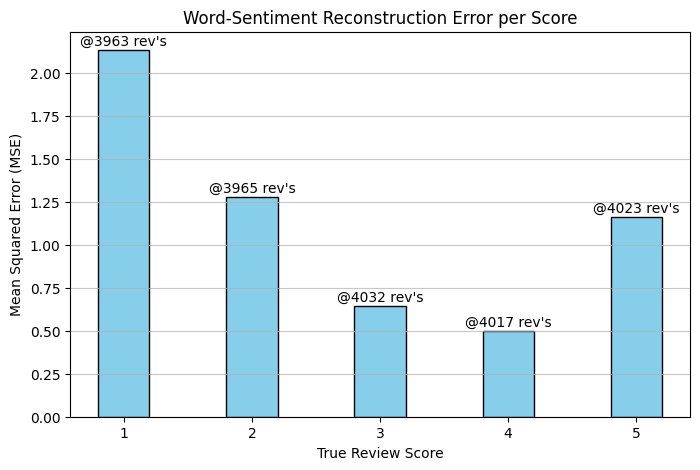

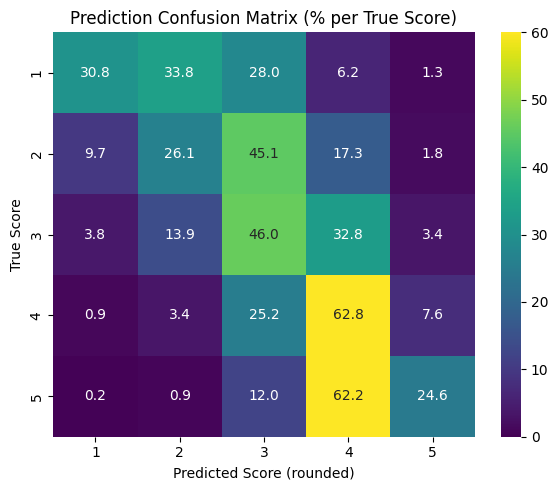

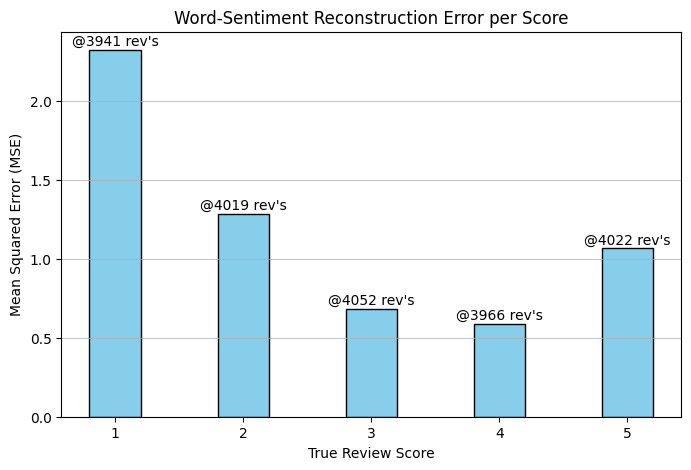

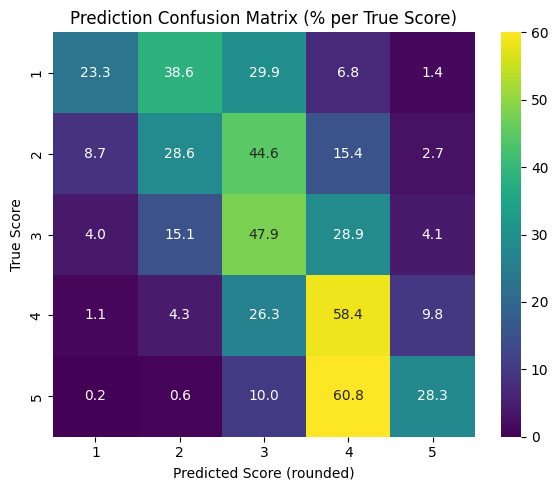

In [14]:
def evaluate_word_sentiment_reconstruction(
    dataset, word_stats, global_mean, global_std, prefix=""
):
    true_scores = []
    pred_scores = []
    n_unknown = 0

    for text, rating in tqdm(dataset, desc="Running test"):
        words = [w for w in re.findall(r"\b\w+\b", text.lower()) if w not in stop_words]
        word_sents = [
            word_stats[w]["sentiment"]
            for w in words
            if w in word_stats and abs(word_stats[w]["sentiment"]) > 0.3
        ]

        if word_sents:
            avg_sent = np.mean(word_sents)
            pred = global_mean + avg_sent * global_std
        else:
            pred = global_mean
            n_unknown += len([w for w in words if w not in word_stats])

        pred = max(1.0, min(5.0, pred))

        true_scores.append(rating)
        pred_scores.append(pred)

    make_analysis(true_scores, pred_scores, prefix=prefix, suffix="baseline")

    return n_unknown

unknown = evaluate_word_sentiment_reconstruction(
    val_ds, word_stats, global_mean, global_std
)
print("Number of unknown words:", unknown)

unknown = evaluate_word_sentiment_reconstruction(
    test_ds, word_stats, global_mean, global_std, prefix="Test_"
)
print("Number of unknown words:", unknown)

## TF-IDF

We are proposing a TF-IDF model using ridge or logistic vectorization as an improved baseline. Below is a from-scratch implementation of it:

In [ ]:
WORD_PATTERN = re.compile(r"\b\w+\b")
# Download stopwords to ./nltk_data
nltk.download("stopwords", quiet=True)
# Load stopwords
stop_words= set(stopwords.words("english"))

class TfidfVectorizer:
    """
    TF-IDF Vectorizer implemented from scratch.
    Mimics scikit-learn's TfidfVectorizer interface.
    """

    def __init__(
        self,
        max_features=None,
        ngram_range=(1, 1),
        min_df=1,
        max_df=1.0,
        lowercase=True,
        strip_accents=None,
    ):
        """
        Initialize TF-IDF Vectorizer.

        Args:
            max_features: Maximum number of features to keep
            ngram_range: Tuple (min_n, max_n) for n-gram range
            min_df: Minimum document frequency (int or float)
            max_df: Maximum document frequency (int or float)
            lowercase: Convert to lowercase
            strip_accents: Not used, kept for compatibility
        """
        self.max_features = max_features
        self.ngram_range = ngram_range
        self.min_df = min_df
        self.max_df = max_df
        self.lowercase = lowercase

        # Will be set during fit
        self.vocabulary_ = None
        self.idf_ = None
        self.feature_names_ = None
    
    def _generate_ngrams(self, tokens):
        """Generate n-grams from a list of tokens."""
        min_n, max_n = self.ngram_range
        n_tokens = len(tokens)

        for n in range(min_n, max_n + 1):
            if n_tokens < n:
                continue
            for i in range(n_tokens - n + 1):
                yield tuple(tokens[i:i+n])

    def _tokenize(self, text):
        """Tokenize text into words."""
        if self.lowercase:
            text = text.lower()

        # Extract words using regex
        words = WORD_PATTERN.findall(text)

        # Filter stopwords and short words
        sw = stop_words
        tokens = [
            w for w in words if w not in sw and len(w) > 1 and w.isalpha()
        ]

        return tokens

    def _build_vocabulary(self, documents):
        """Build vocabulary from documents."""
        # Count document frequencies for each n-gram
        doc_freq = Counter()
        n_docs = len(documents)
        tokenized_docs = []
        ngram_docs = []
        
        for doc in tqdm(documents, desc="Building vocabulary"):
            tokens = self._tokenize(doc)
            tokenized_docs.append(tokens)
        
            ngrams = list(self._generate_ngrams(tokens))
            ngram_docs.append(ngrams)
        
            doc_freq.update(set(ngrams))

        # Filter by min_df and max_df
        min_doc_freq = (
            self.min_df if isinstance(self.min_df, int) else int(self.min_df * n_docs)
        )
        max_doc_freq = (
            self.max_df if isinstance(self.max_df, int) else int(self.max_df * n_docs)
        )

        # Filter vocabulary
        filtered_vocab = {
            ngram: freq
            for ngram, freq in doc_freq.items()
            if min_doc_freq <= freq <= max_doc_freq
        }

        # Select top features if max_features is specified
        if self.max_features and len(filtered_vocab) > self.max_features:
            # Sort by frequency (descending) and take top max_features
            sorted_vocab = sorted(
                filtered_vocab.items(), key=lambda x: x[1], reverse=True
            )[: self.max_features]
            filtered_vocab = dict(sorted_vocab)

        # Create vocabulary mapping (ngram -> index)
        sorted_ngrams = sorted(filtered_vocab.keys())
        self.vocabulary_ = {ngram: idx for idx, ngram in enumerate(sorted_ngrams)}
        self.feature_names_ = [self._ngram_to_string(ngram) for ngram in sorted_ngrams]

        # Calculate IDF for each term
        df_array = np.array([doc_freq[ng] for ng in sorted_ngrams])
        self.idf_ = np.log((n_docs + 1) / (df_array + 1)) + 1

    def _ngram_to_string(self, ngram):
        """Convert n-gram tuple to string representation."""
        if isinstance(ngram, tuple):
            return " ".join(ngram)
        return ngram

    def _compute_tfidf(self, ngrams):
        """compute tf-idf using sparse dict."""
        vocab = self.vocabulary_
        idf = self.idf_

        tf_counts = Counter(ngrams)
        total = len(ngrams)

        if total == 0:
            return np.zeros(len(vocab))

        # sparse row
        row = {}
        norm_factor = 1.0 / total

        for ng, count in tf_counts.items():
            idx = vocab.get(ng)
            if idx is not None:
                row[idx] = (count * norm_factor) * idf[idx]

        # convert sparse dict to dense vector
        vec = np.zeros(len(vocab))
        for idx, val in row.items():
            vec[idx] = val

        return vec


    def fit(self, raw_documents):
        """
        Learn vocabulary and IDF from training documents.

        Args:
            raw_documents: List of raw text documents

        Returns:
            self
        """
        self._build_vocabulary(raw_documents)
        return self
    

    def transform(self, raw_documents):
        """
        Transform documents to TF-IDF matrix.

        Args:
            raw_documents: List of raw text documents

        Returns:
            numpy array of shape (n_documents, n_features)
        """
        if self.vocabulary_ is None:
            raise ValueError("Vectorizer has not been fitted yet. Call fit() first.")

        n_docs = len(raw_documents)
        n_features = len(self.vocabulary_)
        tfidf_matrix = np.zeros((n_docs, n_features))

        for i, doc in enumerate(raw_documents):
            tokens = self._tokenize(doc)
            ngrams = list(self._generate_ngrams(tokens))
            tfidf_matrix[i] = self._compute_tfidf(ngrams)

        return tfidf_matrix


    def fit_transform(self, raw_documents):
        """
        Learn vocabulary and IDF, then transform documents.

        Args:
            raw_documents: List of raw text documents

        Returns:
            numpy array of shape (n_documents, n_features)
        """
        self.fit(raw_documents)
        return self.transform(raw_documents)


def preprocess_text(text):
    words = [
        x.lower()
        for x in WORD_PATTERN.findall(text.lower())
        if x.lower() not in stop_words and len(x) > 1 and x.isalpha()
    ]
    return " ".join(words)


def train_tfidf_model(train_ds, method="ridge", max_features=5000, ngram_range=(1, 2)):
    texts = []
    ratings = []

    print("Preprocessing training data...")
    for text, rating in tqdm(train_ds, desc="Processing reviews"):
        texts.append(preprocess_text(text))
        ratings.append(rating)

    ratings = np.array(ratings)

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=2,
        max_df=0.95,
        lowercase=True,
        strip_accents="unicode",
    )

    print("Vectorizing texts...")
    X_train = vectorizer.fit_transform(texts)

    print(f"TF-IDF matrix shape: {X_train.shape}")
    print(f"Number of features: {X_train.shape[1]}")
    
    # convert to sparse matrix to save computational cost
    X_train = csr_matrix(X_train)

    if method == "ridge":
        model = Ridge(alpha=1.0, random_state=42)
        print("Training Ridge Regression model...")
    elif method == "logistic":
        model = LogisticRegression(
            multi_class="multinomial",
            solver="lbfgs",
            max_iter=1000,
            random_state=42,
            C=1.0,
        )
        print("Training Logistic Regression model...")
    else:
        raise ValueError(f"Unknown method: {method}. Use 'ridge' or 'logistic'")

    model.fit(X_train, ratings)

    return vectorizer, model, method


def predict_tfidf(dataset, vectorizer, model, method, prefix=""):
    texts = []
    true_scores = []

    print("Preprocessing test data...")
    for text, rating in tqdm(dataset, desc="Processing reviews"):
        texts.append(preprocess_text(text))
        true_scores.append(rating)

    print("Vectorizing texts...")
    X_test = vectorizer.transform(texts)

    print("Making predictions...")
    pred_scores = model.predict(X_test)

    pred_scores = np.clip(pred_scores, 1.0, 5.0)
    true_scores = np.array(true_scores)

    suffix = f"tfidf_{method}"
    make_analysis(true_scores, pred_scores, prefix=prefix, suffix=suffix)

    return pred_scores

With the constructive code out of the way, we move to training and testing the model. Since we implemented everything here in python, it will take a while...

In [ ]:
vectorizer_ridge, model_ridge, _ = train_tfidf_model(
    train_ds, method="ridge", max_features=10000, ngram_range=(1, 2)
)
predict_tfidf(val_ds, vectorizer_ridge, model_ridge, "ridge")
predict_tfidf(test_ds, vectorizer_ridge, model_ridge, "ridge", prefix="Test_")

Preprocessing training data...


Processing reviews: 100%|██████████| 160000/160000 [00:05<00:00, 31641.63it/s]


Vectorizing texts...


Building vocabulary: 100%|██████████| 160000/160000 [00:05<00:00, 31042.98it/s]


TF-IDF matrix shape: (160000, 10000)
Number of features: 10000
Training Ridge Regression model...


The same for the logistic model...

In [ ]:
vectorizer_log, model_log, _ = train_tfidf_model(
    train_ds, method="logistic", max_features=10000, ngram_range=(1, 2)
)
predict_tfidf(val_ds, vectorizer_log, model_log, "logistic")
predict_tfidf(test_ds, vectorizer_ridge, model_log, "logistic", prefix="Test_")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Preprocessing training data...


Processing reviews: 100%|██████████| 160000/160000 [00:04<00:00, 32774.14it/s]


Vectorizing texts...
TF-IDF matrix shape: (160000, 10000)
Number of features: 10000
Training Logistic Regression model...


/opt/homebrew/Caskroom/miniforge/base/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## LSH

We implement locality-sensitive hashing to find out if it can capture similarities well enough to be suitable for prediction.

In [ ]:
def get_shingles(text, q=3):
    word_pattern = re.compile(r"\b\w+\b")
    text = "_".join(
        [x for x in word_pattern.findall(text.lower()) if x not in stop_words]
    )
    return {text[i : i + q] for i in range(max(0, len(text) - q + 1))}


class MinHash:
    def __init__(self, num_hashes=100, seed=42):
        self.num_hashes = num_hashes
        self.seed = seed
        self.large_prime = (1 << 61) - 1
        rng = np.random.default_rng(seed)
        self.a = rng.integers(1, self.large_prime, size=num_hashes, dtype=np.uint64)
        self.b = rng.integers(0, self.large_prime, size=num_hashes, dtype=np.uint64)

    def signature(self, shingles):
        if not shingles:
            return np.zeros(self.num_hashes, dtype=np.uint64)
        shingle_hashes = np.array(
            [
                int(hashlib.md5(s.encode()).hexdigest(), 16) & ((1 << 64) - 1)
                for s in shingles
            ],
            dtype=np.uint64,
        )
        hashes = (np.outer(self.a, shingle_hashes) + self.b[:, None]) % self.large_prime
        return hashes.min(axis=1)


class LSHIndex:
    def __init__(self, num_hashes=100, bands=20):
        self.num_hashes = num_hashes
        self.bands = bands
        self.rows = num_hashes // bands
        self.tables = [defaultdict(list) for _ in range(bands)]
        self.signatures = []
        self.labels = []

    def add(self, signature, label):
        idx = len(self.signatures)
        self.signatures.append(signature)
        self.labels.append(label)
        for b in range(self.bands):
            start = b * self.rows
            end = (b + 1) * self.rows
            band_hash = hashlib.md5(signature[start:end].tobytes()).hexdigest()
            self.tables[b][band_hash].append(idx)

    def query(self, signature):
        candidates = set()
        for b in range(self.bands):
            start = b * self.rows
            end = (b + 1) * self.rows
            band_hash = hashlib.md5(signature[start:end].tobytes()).hexdigest()
            candidates.update(self.tables[b].get(band_hash, []))
        return list(candidates)

    def predict_label(self, signature, top_k=1):
        candidates = self.query(signature)
        if not candidates:
            return None, []

        sims = []
        for idx in candidates:
            sim = np.mean(self.signatures[idx] == signature)
            sims.append((sim, self.labels[idx]))

        sims.sort(reverse=True)
        top_sims = sims[:top_k]

        total_sim = sum(sim for sim, _ in top_sims)
        if total_sim == 0:
            avg_label = np.mean([label for _, label in top_sims])
        else:
            avg_label = sum(sim * label for sim, label in top_sims) / total_sim

        return avg_label, top_sims


def estimate_ratings(dataset, lsh, minhash, prefix=""):
    true_scores = []
    pred_scores = []
    n_unknown = 0

    for text, rating in tqdm(dataset, desc="Running test"):
        sig = minhash.signature(get_shingles(text))
        pred, _ = lsh.predict_label(sig, 5)
        if pred is None:
            pred = 3.0
            n_unknown += 1
        true_scores.append(rating)
        pred_scores.append(pred)

    make_analysis(true_scores, pred_scores, prefix=prefix, suffix="lsh")

    return n_unknown


def build_lsh_index(train_ds, num_hashes=180, bands=60, cache_dir="cache"):
    minhash = MinHash(num_hashes=num_hashes)
    lsh = LSHIndex(num_hashes=num_hashes, bands=bands)

    os.makedirs(cache_dir, exist_ok=True)

    cache_sig_path = os.path.join(cache_dir, "lsh_signatures.npy")
    cache_rat_path = os.path.join(cache_dir, "lsh_ratings.npy")

    signatures_data = None
    ratings_data = None

    if os.path.exists(cache_sig_path) and os.path.exists(cache_rat_path):
        print(f"Trying to load from cache file {cache_sig_path}...")
        try:
            signatures_data = np.load(cache_sig_path)
            ratings_data = np.load(cache_rat_path)
            print(f"Loaded {len(signatures_data)} signatures from cache.")
        except Exception as e:
            print(f"Error while loading cache: {e}. Recomputing...")

    if signatures_data is None:
        print("Computing signatures for LSH...")
        sig_list = []
        rat_list = []

        for text, rating in tqdm(train_ds, desc="Hashing"):
            shingles = get_shingles(text)
            if not shingles:
                continue

            sig = minhash.signature(shingles)
            sig_list.append(sig)
            rat_list.append(rating)

        signatures_data = np.array(sig_list)
        ratings_data = np.array(rat_list)

        print("Saving cache...")
        np.save(cache_sig_path, signatures_data)
        np.save(cache_rat_path, ratings_data)

    print("Costruct LSH indices...")
    num_items = len(signatures_data)
    for i in tqdm(range(num_items), desc="Populating Index"):
        lsh.add(signatures_data[i], ratings_data[i])
    return lsh, minhash

The above framework is now used to build the LSH index and we test the estimation quality:

Computing signatures for LSH...


Hashing: 100%|██████████| 160000/160000 [00:30<00:00, 5256.33it/s]


Saving cache...
Costruct LSH indices...


Running test: 100%|██████████| 20000/20000 [03:54<00:00, 85.14it/s] 


Overall MSE: 1.2339
Number of unknown scores: 18 out of 20000


Running test: 100%|██████████| 20000/20000 [03:15<00:00, 102.32it/s]


Overall MSE: 1.2331
Number of unknown scores: 9 out of 20000


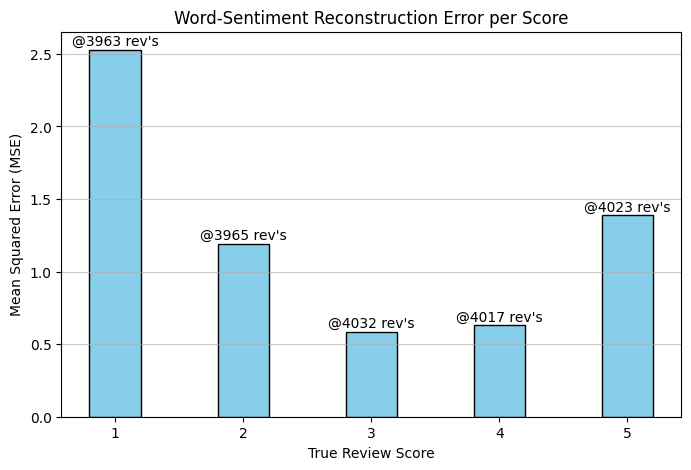

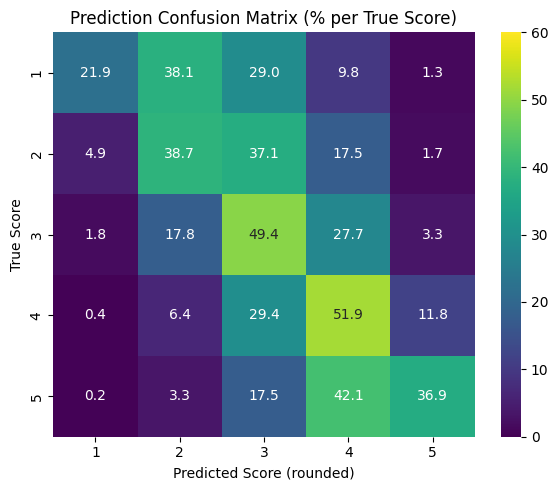

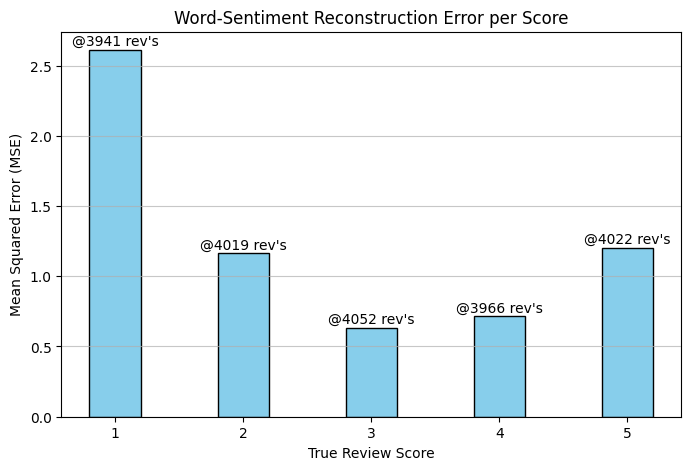

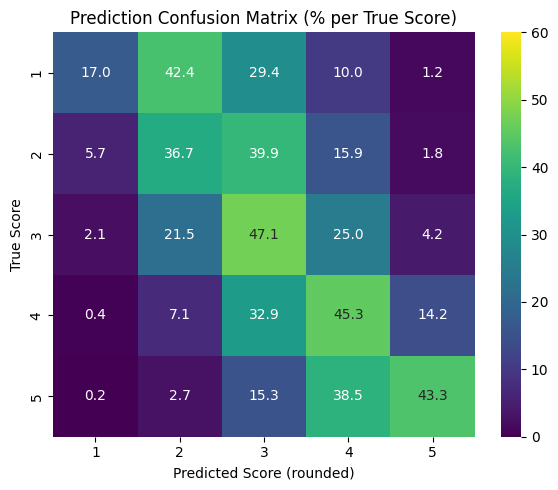

In [7]:
lsh, minhash = build_lsh_index(train_ds, num_hashes=180, bands=60, cache_dir=os.path.join(PROJECT_ROOT, "cache"))

unknown = estimate_ratings(val_ds, lsh, minhash)
print("Number of unknown scores:", unknown, "out of", len(test_ds))

unknown = estimate_ratings(test_ds, lsh, minhash, prefix="Test_")
print("Number of unknown scores:", unknown, "out of", len(test_ds))

## Clustering

Performance of LSH did not impress. Instead, we will now look into clustering. Since we are working with large datasets, we implement MiniBatchKMeans.

In [ ]:
class MiniBatchKMeans:
    def __init__(self, n_clusters=8, batch_size=256, max_iter=100, random_state=None):
        self.n_clusters = n_clusters
        self.batch_size = batch_size
        self.max_iter = max_iter
        self.random_state = np.random.RandomState(random_state)

        self.cluster_centers_ = None

    def _init_centers(self, X):
        """Randomly choose k samples as initial centers."""
        idx = self.random_state.choice(len(X), self.n_clusters, replace=False)
        centers = X[idx].astype(np.float64)
        # normalize for spherical kmeans
        centers /= np.linalg.norm(centers, axis=1, keepdims=True) + 1e-12
        return centers

    def _closest_center(self, X, centers):
        """
        Based on relationship: ||u-v||^2 = 2 - 2*cos(u,v)  if ||u||=||v||=1 
        Compute nearest cluster with spherical distance:
        dist = sqrt(2 - 2 cos θ)
        Equivalent to maximizing dot(X, centers).
        """
        sims = np.dot(X, centers.T)   # cosine similarity (since normalized)
        return np.argmax(sims, axis=1)

    def fit(self, X):
        X = np.asarray(X, dtype=np.float64)

        if self.cluster_centers_ is None:
            self.cluster_centers_ = self._init_centers(X)

        counts = np.zeros(self.n_clusters, dtype=np.int64)

        for _ in range(self.max_iter):
            # sample mini-batch
            idx = self.random_state.choice(len(X), self.batch_size, replace=False)
            batch = X[idx]

            # assign points to closest center
            labels = self._closest_center(batch, self.cluster_centers_)

            # update centers using online k-means update rule
            for i, x in zip(labels, batch):
                counts[i] += 1
                eta = 1.0 / counts[i]    # learning rate
                self.cluster_centers_[i] = (1 - eta) * self.cluster_centers_[i] + eta * x
                # re-normalize for spherical kmeans
                self.cluster_centers_[i] /= (
                    np.linalg.norm(self.cluster_centers_[i]) + 1e-12
                )

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)
        return self._closest_center(X, self.cluster_centers_)

    def fit_predict(self, X):
        self.fit(X)
        return self.predict(X)

def plot_cluster_spread(stats, savepath=None):
    plt.figure(figsize=(8, 4))
    x = np.linspace(1, 5, 100)
    colors = {1: "r", 2: "y", 3: "g", 4: "b", 5: "m"}
    for mean, std, rating in stats:
        y = norm.pdf(x, mean, std)
        plt.plot(x, y, alpha=3 / len(stats), color=colors[rating])
        plt.fill_between(x, y, alpha=1.5 / len(stats), color=colors[rating])
    plt.xlabel("Score")
    plt.ylabel("Certainty")
    plt.yticks([])
    plt.title("Cluster score distribution")
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath)
    else:
        plt.show()


def transformer_kmeans_clustering(
    dataset, model, tokenizer, k=50, cache_name="kmeans_embeddings", cache_dir=None
):
    """
    Perform K-means clustering on transformer embeddings.

    Args:
        dataset: Dataset of (text, rating) pairs
        k: Number of clusters
        cache_suffix: Suffix for cache file name
        cache_dir: Directory for cache files (defaults to cache/ in project root)

    Returns:
        model, kmeans, cluster_ratings, cluster_stats
    """
    os.makedirs(cache_dir, exist_ok=True)
    cache_vec = os.path.join(cache_dir, f"{cache_name}_vecs.npy")

    embeddings = None
    ratings = np.array([rating for _, rating in dataset])

    if os.path.exists(cache_vec):
        print(f"Found cache {cache_vec}, loading...")
        try:
            embeddings = np.load(cache_vec)
            print(f"Loaded {len(embeddings)} embeddings.")
        except Exception as e:
            print("Error loading cache:", e)

    if embeddings is None:
        print("Encoding sentence-transformer embeddings for dataset...")
        texts = [text for text, _ in dataset]

        embeddings = encode_texts(model, tokenizer, texts)
        embeddings = normalize(embeddings, norm="l2", axis=1)
        print("Saving embedding cache...")
        np.save(cache_vec, embeddings)

    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=3072)
    clusters = kmeans.fit_predict(embeddings)

    cluster_ratings = {}
    cluster_stats = []
    for i in range(k):
        current_cluster_ratings = ratings[clusters == i]

        if len(current_cluster_ratings) == 0:
            cluster_ratings[i] = 3.0
            cluster_stats.append((3.0, 0.0, 3.0))
            continue

        cluster_ratings[i] = np.bincount(current_cluster_ratings.astype(int)).argmax()

        cluster_stats.append(
            (
                np.mean(current_cluster_ratings),
                np.std(current_cluster_ratings),
                cluster_ratings[i],
            )
        )

    plots_dir = os.path.join(PROJECT_ROOT, "plots")
    os.makedirs(plots_dir, exist_ok=True)
    plot_cluster_spread(
        cluster_stats, savepath=os.path.join(plots_dir, "Cluster_Distribution.png")
    )

    return model, kmeans, cluster_ratings, cluster_stats


def transformer_clustering_predict(
    dataset, model, tokenizer, kmeans, ratings, prefix="", x=15
):
    texts = [text for text, _ in dataset]

    embeddings = encode_texts(model, tokenizer, texts)
    embeddings = normalize(embeddings, norm="l2", axis=1)

    centers = normalize(kmeans.cluster_centers_, norm="l2", axis=1)
    dists = cdist(embeddings, centers, metric="euclidean")
    nearest_indices = np.argsort(dists, axis=1)[:, :x]
    nearest_dists = np.take_along_axis(dists, nearest_indices, axis=1)

    n_clusters = kmeans.n_clusters
    cluster_scores = np.array([ratings[i] for i in range(n_clusters)], dtype=np.float64)

    weights = 1.0 / (nearest_dists + 1e-8)
    weights_sum = weights.sum(axis=1, keepdims=True)
    weights_sum[weights_sum == 0] = 1.0
    weights = weights / weights_sum

    nearest_scores = cluster_scores[nearest_indices]
    pred_scores = np.sum(nearest_scores * weights, axis=1)
    true_scores = np.array([rating for _, rating in dataset], dtype=np.float64)

    make_analysis(true_scores, pred_scores, prefix=prefix, suffix="kmeans")
    return 0

Now let us test the clustering:

Found cache ./cache/kmeans_embeddings_vecs.npy, loading...
Loaded 160000 embeddings.
Overall MSE: 0.8762
Overall MSE: 0.9081


0

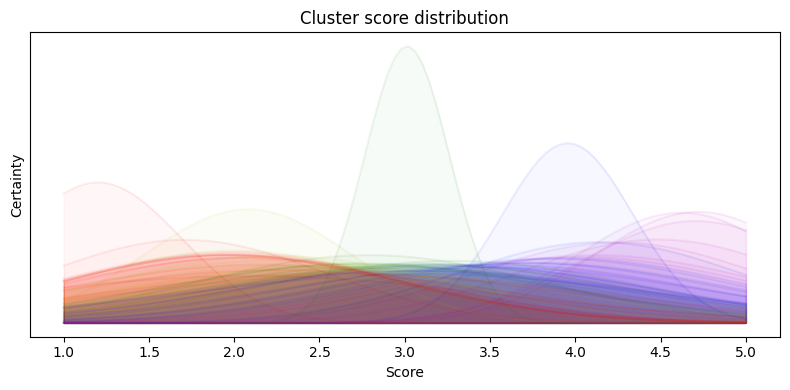

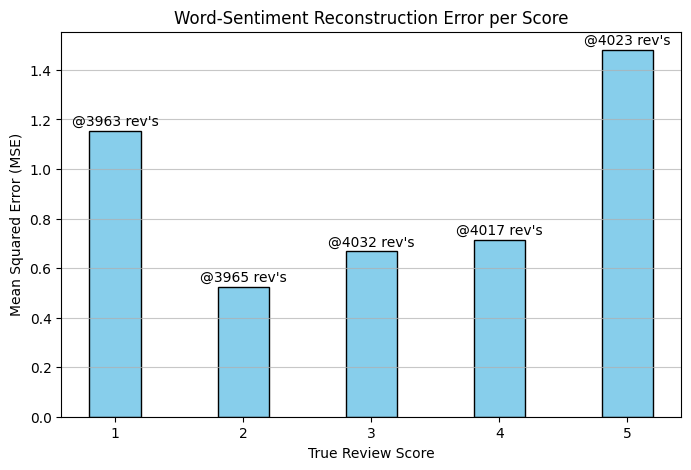

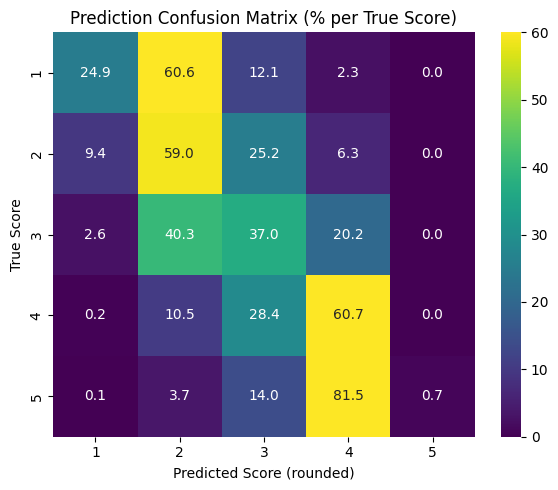

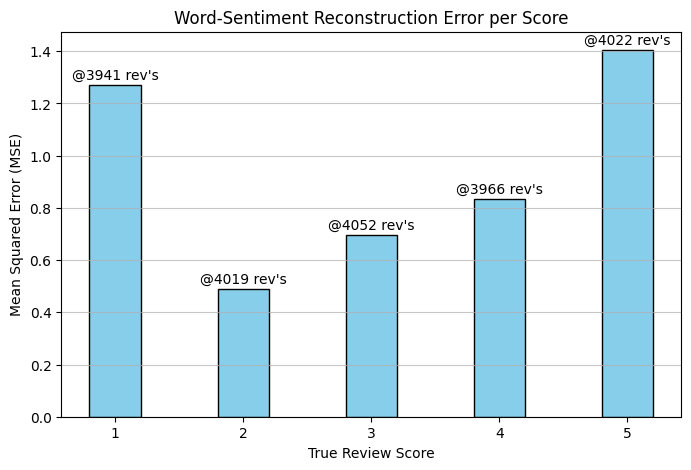

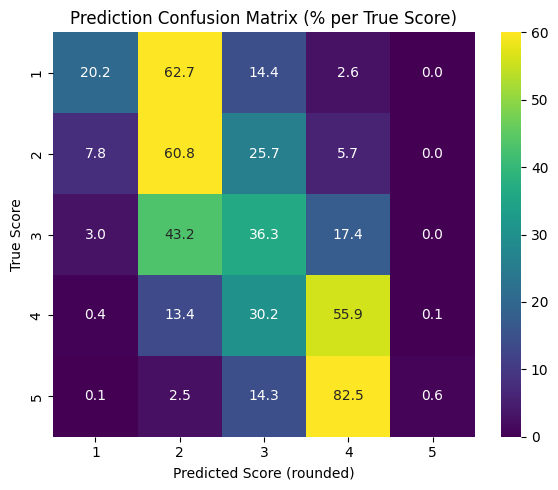

In [4]:
cache_dir = os.path.join(PROJECT_ROOT, "cache")

model, kmeans, cluster_ratings, stats = transformer_kmeans_clustering(
    train_ds,
    model,
    tokenizer,
    k=50,
    cache_dir=cache_dir,
)

transformer_clustering_predict(val_ds, model, tokenizer, kmeans, cluster_ratings)

transformer_clustering_predict(
    test_ds, model, tokenizer, kmeans, cluster_ratings, prefix="Test_"
)

## IndexFlatIP (as in FAISS)

Clustering showed decent results, but it tended to "push" the results further towards the center, potentially due to a too strong deviation in each cluster. We will now look at IndexFlatIP which is a function built into the FAISS library. We implement it ourselves to get a better understanding of how it works.

In [ ]:
class IndexFlatIP:
    def __init__(self, dim, normalize_vectors=False):
        self.dim = dim
        self.normalize_vectors = normalize_vectors
        self._embeddings = []
        self._labels = []
        self._matrix = None
        self._built = False

    def _maybe_normalize(self, v):
        v = np.asarray(v, dtype=np.float32)
        if self.normalize_vectors:
            n = np.linalg.norm(v)
            if n > 0:
                v = v / n
        return v

    def _ensure_matrix(self):
        """Stack all embeddings into a search matrix when needed."""
        if not self._built:
            if self._embeddings:
                self._matrix = np.vstack(self._embeddings).astype(np.float32)
            else:
                self._matrix = np.zeros((0, self.dim), dtype=np.float32)
            self._built = True

    def add(self, signature, label):
        """Add one embedding + label. Keeps name 'signature' for compatibility."""
        v = self._maybe_normalize(signature)
        if v.shape[-1] != self.dim:
            raise ValueError(f"Expected dim {self.dim}, got {v.shape}")
        self._embeddings.append(v)
        self._labels.append(float(label))
        self._built = False

    def query(self, signature, top_k=None):
        """Return nearest neighbor indices sorted by similarity."""
        if len(self._embeddings) == 0:
            return []

        self._ensure_matrix()
        q = self._maybe_normalize(signature)
        sims = self._matrix @ q  # dot product

        n = sims.shape[0]
        if top_k is None or top_k >= n:
            idx_sorted = np.argsort(-sims)
        else:
            idx_part = np.argpartition(-sims, top_k - 1)[:top_k]
            idx_sorted = idx_part[np.argsort(-sims[idx_part])]

        return idx_sorted.tolist()

    def predict_label(self, signature, top_k=1):
        """Predict rating as similarity-weighted mean of nearest neighbors."""
        if len(self._embeddings) == 0:
            return None, []

        self._ensure_matrix()
        q = self._maybe_normalize(signature)
        sims = self._matrix @ q
        n = sims.shape[0]
        k = min(top_k, n)

        idx_part = np.argpartition(-sims, k - 1)[:k]
        idx_sorted = idx_part[np.argsort(-sims[idx_part])]

        top_sims = sims[idx_sorted]
        top_labels = np.array([self._labels[i] for i in idx_sorted], dtype=np.float32)

        # Clamp negative similarities (cosine can be negative)
        weights = np.maximum(top_sims, 0.0)
        total = float(weights.sum())

        if total == 0:
            avg_label = float(top_labels.mean())
        else:
            avg_label = float((weights * top_labels).sum() / total)

        neighbors = list(zip(top_sims.tolist(), top_labels.tolist()))
        return avg_label, neighbors


def build_embedding_index(
    train_ds, model, tokenizer, cache_dir, cache_name="faiss_embeddings"
):
    os.makedirs(cache_dir, exist_ok=True)

    cache_vec = os.path.join(cache_dir, f"{cache_name}_vecs.npy")
    cache_rat = os.path.join(cache_dir, f"{cache_name}_ratings.npy")

    embeddings_data = None
    ratings_data = None

    if os.path.exists(cache_vec) and os.path.exists(cache_rat):
        print(f"Found cache {cache_vec}, loading...")
        try:
            embeddings_data = np.load(cache_vec)
            ratings_data = np.load(cache_rat)
            print(f"Loaded {len(embeddings_data)} embeddings.")
        except Exception as e:
            print("Error loading cache:", e)

    if embeddings_data is None:
        print("Encoding sentence-transformer embeddings for training set...")
        texts = [text for text, _ in train_ds]
        ratings = [rating for _, rating in train_ds]

        embeddings = encode_texts(model, tokenizer, texts)
        embeddings = normalize(embeddings, norm="l2", axis=1).astype(np.float32)

        embeddings_data = embeddings
        ratings_data = np.array(ratings, dtype=np.float32)

        print("Saving embedding cache...")
        np.save(cache_vec, embeddings_data)
        np.save(cache_rat, ratings_data)

    dim = embeddings_data.shape[1]
    index = IndexFlatIP(dim=dim, normalize_vectors=False)

    print("Building IndexFlatIP model...")
    for vec, rating in zip(embeddings_data, ratings_data):
        index.add(vec, rating)

    return index


def estimate_ratings_with_embeddings(
    dataset, index, model, tokenizer, prefix="", batch_size=64
):
    true_scores = []
    pred_scores = []
    n_unknown = 0

    texts = [text for text, _ in dataset]
    ratings = [rating for _, rating in dataset]

    for start in tqdm(range(0, len(texts), batch_size), desc="Running test"):
        end = min(start + batch_size, len(texts))
        batch_texts = texts[start:end]
        batch_ratings = ratings[start:end]

        # Encode & normalize
        batch_emb = encode_texts(model, tokenizer, batch_texts)
        batch_emb = normalize(batch_emb, norm="l2", axis=1).astype(np.float32)

        for emb, rating in zip(batch_emb, batch_ratings):
            pred, _ = index.predict_label(emb, top_k=5)
            if pred is None:
                pred = 3.0
                n_unknown += 1

            true_scores.append(rating)
            pred_scores.append(pred)

    make_analysis(true_scores, pred_scores, prefix=prefix, suffix="faiss")
    return n_unknown

Lets look at the performance:

Encoding sentence-transformer embeddings for training set...
Saving embedding cache...
Building IndexFlatIP model...


Running test: 100%|██████████| 313/313 [01:30<00:00,  3.46it/s]


Overall MSE: 0.8811


Running test: 100%|██████████| 313/313 [01:22<00:00,  3.79it/s]


Overall MSE: 0.9135


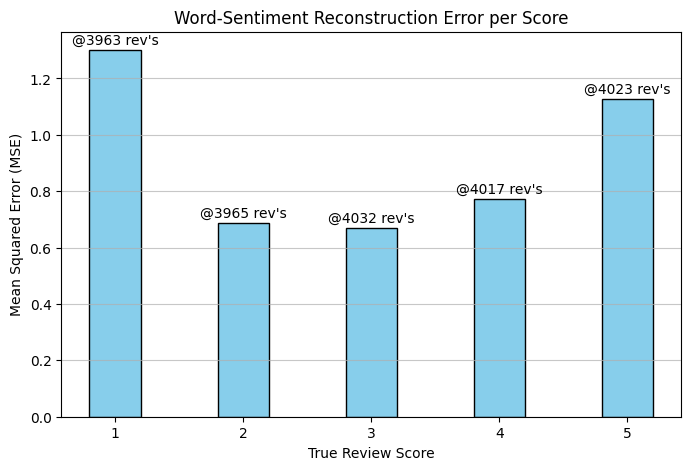

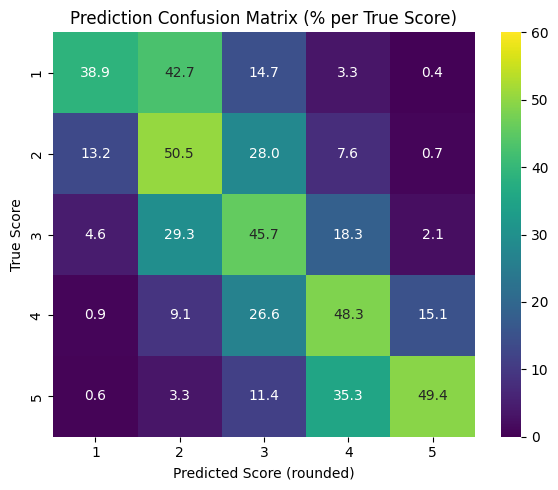

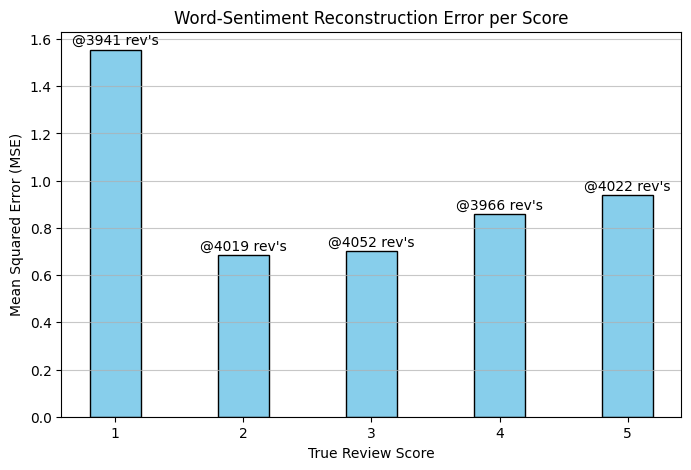

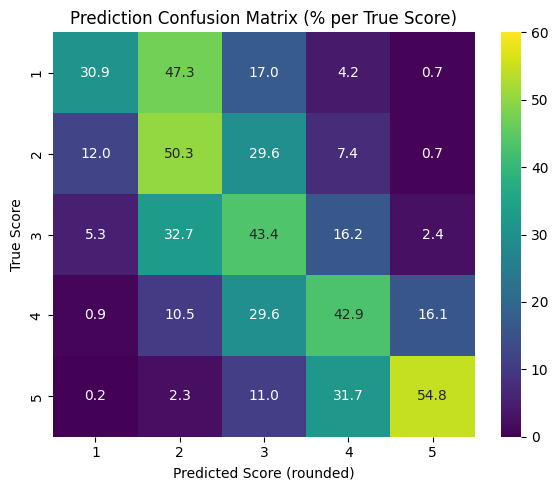

In [9]:
cache_dir = os.path.join(PROJECT_ROOT, "cache")
index = build_embedding_index(train_ds, model, tokenizer, cache_dir)

unknown = estimate_ratings_with_embeddings(val_ds, index, model, tokenizer)

unknown = estimate_ratings_with_embeddings(
    test_ds, index, model, tokenizer, prefix="Test_"
)